## 하이퍼 파라미터 

- 이 값들은 모델 학습 과정 자체에 의해 학습되지 않으며, 모델의 성능에 큰 영향을 미칠 수 있다. 
- learning rate, tree depth, batch size, epochs number 등이 있으며 사용할 모델의 종류마다 다르다. 

### 릿지(Ridge) 회귀 모델 

- Ridge 회귀는 선형 회귀의 일종으로, 선형 회귀 모델의 손실함수 MSE(Mean Square Error)에서 규제 (regularization)가 추가된 모델이다. 
$$ MSE + 규제 $$

- Ridge회귀에서 사용하는 규제는 L2규제라고도 하며, 모델의 계수의 제곱합을 규제항으로 사용 
- 이 규제 항이 비용함수 (cost function)에 추가되어 모델이 학습하는 동안 계수의 크기가 커지는 것을 제한 


In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# 연습용 데이터 생성
X, y = make_regression(n_samples=100, n_features=2, noise=0.1, random_state=1)

# 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

from sklearn.linear_model import Ridge

ridge_model = Ridge() # 모델 객체 정의 , model = Ridge(alpah=alpha_value) # alpha_value: 정규화 강도 조절, 기본값은 1.0 -> 적절한 alpha_value 값은 데이터에 따라 다르므로 실험적으로 찾아야 함
ridge_model

(80, 2)
(80,)
(20, 2)
(20,)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [3]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(ridge_model, X_train, y_train, scoring='neg_mean_squared_error')
scores # 교차검증 neg_MSE 점수

array([-2.83839588, -2.27326453, -3.15435097, -2.3522752 , -5.7908437 ])

## alpha 값에 따른 모델의 성능 변화 확인 

# 릿지 회귀의 Loss(비용 함수) 수식
릿지 회귀(Ridge Regression)는 기존 선형 회귀의 오차(RSS)에 가중치의 제곱합(L2 규제)을 더한 비용 함수를 사용합니다.


$$ \text{Loss} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^{p} w_j^2 $$

- $y_i$: 실제 값
- $\hat{y}_i$: 예측 값
- $\alpha$: 규제 강도 (패널티 항)
- $w_j$: 회귀 계수 (가중치)

### 추가 자료
- [Scikit-Learn: Ridge Regression](https://scikit-learn.org/stable/modules/linear_model.html#ridge-regression)
- [Wikipedia: Tikhonov regularization (Ridge)](https://en.wikipedia.org/wiki/Tikhonov_regularization)

In [4]:
import numpy as np
from sklearn.model_selection import KFold

# K-Fold 교차 검증 설정
kf = KFold(n_splits=5, shuffle=True, random_state=40)

# alpha 값의 후보 리스트
alpha_list = [0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007, 0.0008]
scores_list = []

# 각 alpha에 대한 교차 검증 수행
for alpha in alpha_list:
    ridge_model = Ridge(alpha=alpha) # 모델 객체 정의, alpha값 설정
    scores = cross_val_score(ridge_model, X_train, y_train, scoring='neg_mean_squared_error', cv=kf) # 교차검증
    scores_list.append(np.mean(scores)) # 점수 저장

scores_list

[np.float64(-0.00996157466023392),
 np.float64(-0.009961313424795809),
 np.float64(-0.009961114852548716),
 np.float64(-0.009960978942645263),
 np.float64(-0.009960905694239568),
 np.float64(-0.009960895106484745),
 np.float64(-0.009960947178534208),
 np.float64(-0.009961061909541317)]

# 최고 득점에서의 alpha값

In [5]:
# 최적 alpha 값 및 성능 확인
best_score = max(scores_list) # 최고득점
print(f"Best Score: {best_score}")

optimal_alpha = alpha_list[np.argmax(scores_list)] # 최고득점에서의 alpha값
print(f"Optimal alpha: {optimal_alpha}")

Best Score: -0.009960895106484745
Optimal alpha: 0.0006


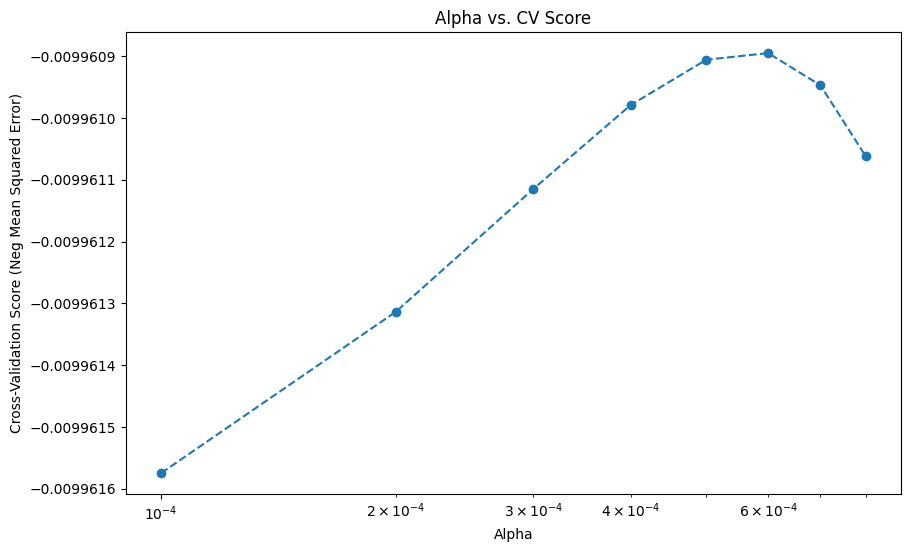

In [6]:
import matplotlib.pyplot as plt

# 결과 시각화
plt.figure(figsize=(10,6))
plt.plot(alpha_list, scores_list, marker='o', linestyle='--')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validation Score (Neg Mean Squared Error)')
plt.title('Alpha vs. CV Score')
plt.xscale('log')
plt.show()

# Exercise 당뇨병 위험 분류 예측 


In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# load_diabetes 데이터셋 로드 (이번에는 feature_names 포함)
diabetes_data = load_diabetes()
X, y = diabetes_data.data, diabetes_data.target
feature_names = diabetes_data.feature_names

# 훈련 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Numpy 배열을 Pandas DataFrame으로 변환 (이번에는 feature_names 사용)
X_train_df = pd.DataFrame(X_train, columns=feature_names)
y_train_df = pd.DataFrame(y_train, columns=["target"])

X_test_df = pd.DataFrame(X_test, columns=feature_names)
y_test_df = pd.DataFrame(y_test, columns=["target"])

# 변환된 데이터셋의 처음 몇 줄을 확인
display(X_train_df.head())
display(y_train_df.head())

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
1,0.012648,0.050680,0.000261,-0.011420,0.039710,0.057245,-0.039719,0.056081,0.024055,0.032059
2,0.070769,-0.044642,0.012117,0.042529,0.071357,0.053487,0.052322,-0.002592,0.025395,-0.005220
3,-0.056370,-0.044642,-0.011595,-0.033213,-0.046975,-0.047660,0.004460,-0.039493,-0.007977,-0.088062
4,-0.070900,0.050680,-0.089197,-0.074527,-0.042848,-0.025739,-0.032356,-0.002592,-0.012909,-0.054925


,target
0,104.0
1,259.0
2,143.0
3,190.0
4,104.0


Optimal alpha: 0.05
Best Score: -3031.3111796421226


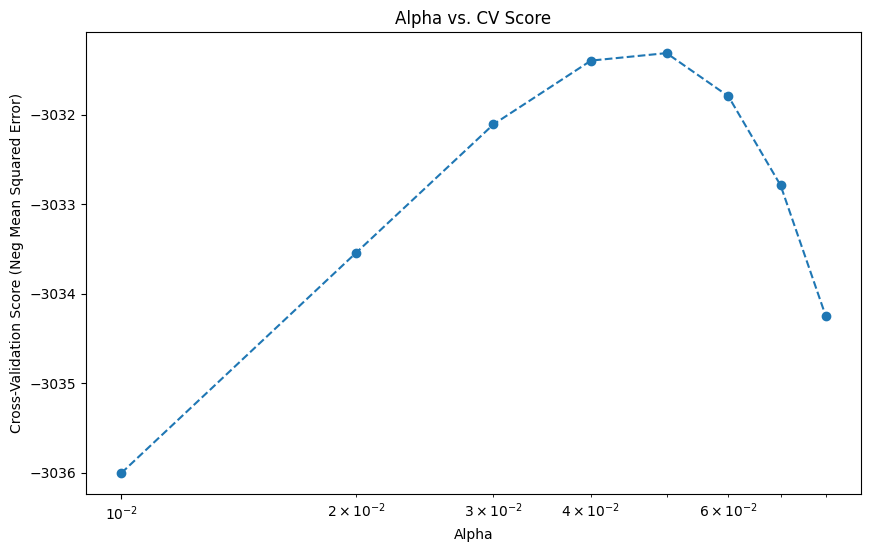

In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold

# K-Fold 교차 검증 설정
kf = KFold(n_splits=5, shuffle=True, random_state=40)

# alpha 값의 후보 리스트
alpha_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08]
scores_list = []

# 각 alpha에 대한 교차 검증 수행
# 여기서 실행해 보세요.
for alpha in alpha_list:
    ridge_model = Ridge(alpha=alpha) # 모델을 학습해 보세요.
    scores = cross_val_score(ridge_model, X_train_df, y_train_df, scoring='neg_mean_squared_error', cv=kf) #결과: [-0.015, -0.012, -0.018, -0.014, -0.011] (예시, 5개의 점수)
    scores_list.append(np.mean(scores))

# 최적 alpha 값 및 성능 확인
optimal_alpha = alpha_list[np.argmax(scores_list)]# 최고득점에서의 alpha값
best_score = max(scores_list)# 최고득점
print(f"Optimal alpha: {optimal_alpha}")
print(f"Best Score: {best_score}")

# 결과 시각화
plt.figure(figsize=(10,6))
plt.plot(alpha_list, scores_list, marker='o', linestyle='--')
plt.xlabel('Alpha')
plt.ylabel('Cross-Validation Score (Neg Mean Squared Error)')
plt.title('Alpha vs. CV Score')
plt.xscale('log')
plt.show()